<a href="https://colab.research.google.com/github/Maziger/Laksegate-master-thesis/blob/main/POC/huggingface_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# POC for hugging face models

The aim is to try and predict electricity prices based on public HF-libraries.

In [2]:
# Setup
import os
from google.colab import userdata

# remove local directory if it already exists
#if os.path.isdir(repo):
#    !rm -rf {repo}

!git clone https://github.com/Maziger/Laksegate-master-thesis.git
%cd Laksegate-master-thesis/

import pandas as pd
path = "POC/Forecasts_DE_DNN_LEAR_ensembles.csv"
data = pd.read_csv(path)
data = data[['Unnamed: 0', 'Real price']]
train = data[:14000]
test = data[14000:]

Cloning into 'Laksegate-master-thesis'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 27 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 1.40 MiB | 10.80 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/Laksegate-master-thesis


# Google TS forecast

Forecasting with Googles TS model: https://huggingface.co/google/timesfm-1.0-200m

In [3]:
# Logging in to Hugging Face and wandb
import os
from google.colab import userdata
from huggingface_hub import login as login_hf
from wandb import login as login_wandb
os.environ['HF_TOKEN'] = userdata.get('HF')
os.environ['WANDB_TOKEN'] = userdata.get('wandb')
os.environ['HF_USER'] = userdata.get('HF_USER')
login_hf(os.environ['HF_TOKEN'])
login_wandb(key = os.environ['WANDB_TOKEN'])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: simonmellergaard (simonmellergaard-aarhus-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
!git clone https://github.com/google-research/timesfm.git
%cd timesfm

Cloning into 'timesfm'...
remote: Enumerating objects: 1301, done.
remote: Counting objects: 100% (607/607), done.
remote: Compressing objects: 100% (265/265), done.
remote: Total 1301 (delta 456), reused 343 (delta 342), pack-reused 694 (from 2)
Receiving objects: 100% (1301/1301), 2.28 MiB | 14.30 MiB/s, done.
Resolving deltas: 100% (694/694), done.


In [17]:
# Activate the environment
!source .venv/bin/activate

In [11]:
# Create a virtual environment
!uv venv

# Activate the environment
!source .venv/bin/activate

# Install the package in editable mode with torch
!uv pip install -e .[torch]
# Or with flax
!uv pip install -e .[flax]
# Or XReg is needed
!uv pip install -e .[xreg]

Using CPython 3.12.12 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Activate with: source .venv/bin/activate
Using Python 3.12.12 environment at: /usr
Resolved 33 packages in 296ms
Prepared 1 package in 1.44s
Installed 1 package in 1ms
 + timesfm==2.0.0 (from file:///content/Laksegate-master-thesis/timesfm)
Using Python 3.12.12 environment at: /usr
Resolved 65 packages in 365ms
Prepared 18 packages in 56.99s
Uninstalled 1 package in 0.50ms
Installed 18 packages in 45ms
 + einshape==1.0
 + jax-cuda12-pjrt==0.7.2
 + jax-cuda12-plugin==0.7.2
 + jaxtyping==0.3.9
 + nvidia-cublas-cu12==12.9.1.4
 + nvidia-cuda-cccl-cu12==12.9.27
 + nvidia-cuda-cupti-cu12==12.9.79
 + nvidia-cuda-nvcc-cu12==12.9.86
 + nvidia-cuda-nvrtc-cu12==12.9.86
 + nvidia-cuda-runtime-cu12==12.9.79
 + nvidia-cudnn-cu12==9.19.0.56
 + nvidia-cufft-cu12==11.4.1.4
 + nvidia-cusolver-cu12==11.7.5.82
 + nvidia-cusparse-cu12==12.5.10.65
 + nvidia-nvjitlink-cu12==12.9.86
 + nvidia-nvshmem-cu12==3.5.19
 ~ 

In [ ]:
#!python -m pip install -e .

In [23]:
if True:
    import IPython
    app = IPython.Application.instance()
    app.kernel.do_shutdown(True)

# Task
Prepare the 'Real price' column from the training data for TimesFM, load the 'google/timesfm-1.0-200m' model, generate forecasts for the test data, and then visualize these forecasts against the actual values to evaluate the model's performance on electricity price prediction.

## Prepare Data for TimesFM

### Subtask:
Extract the 'Real price' column from the training data and format it as a list of numpy arrays, which is the expected input format for the TimesFM model. Determine the forecast horizon based on the length of the test data.


In [9]:
import pandas as pd
import numpy as np
import os

# Re-define train and test DataFrames as they were not found in the current kernel state.
# The current working directory is /content/Laksegate-master-thesis/timesfm.
# The data file is located at /content/Laksegate-master-thesis/POC/Forecasts_DE_DNN_LEAR_ensembles.csv.
# Using the absolute path to ensure correct file loading.

# The base directory where 'Laksegate-master-thesis' was cloned
base_repo_path = "/content/Laksegate-master-thesis"
path = os.path.join(base_repo_path, "POC", "Forecasts_DE_DNN_LEAR_ensembles.csv")

print(f"Attempting to load data from: {path}")

data = pd.read_csv(path)
data = data[['Unnamed: 0', 'Real price']]
train = data[:14000]
test = data[14000:]

preprocessed_data = [train['Real price'].to_numpy()]
forecast_horizon = len(test)

print(f"Shape of preprocessed_data[0]: {preprocessed_data[0].shape}")
print(f"Forecast Horizon: {forecast_horizon}")

Attempting to load data from: /content/Laksegate-master-thesis/POC/Forecasts_DE_DNN_LEAR_ensembles.csv
Shape of preprocessed_data[0]: (14000,)
Forecast Horizon: 3472


## Load TimesFM Model

### Subtask:
Import the TimesFm class and instantiate the pre-trained 'google/timesfm-1.0-200m' model from Hugging Face.


In [11]:
import torch
import numpy as np
import timesfm

torch.set_float32_matmul_precision("high")

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)
point_forecast, quantile_forecast = model.forecast(
    horizon=12,
    inputs=[
        np.linspace(0, 1, 100),
        np.sin(np.linspace(0, 20, 67)),
    ],  # Two dummy inputs
)
point_forecast.shape  # (2, 12)
quantile_forecast.shape  # (2, 12, 10): mean, then 10th to 90th quantiles.

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

Downloaded.


(2, 12, 10)

# Task
Prepare the 'Real price' column from the training data in `POC/Forecasts_DE_DNN_LEAR_ensembles.csv` for the TimesFM model, determining the forecast horizon from the test data. Load and compile the pre-trained `google/timesfm-2.5-200m-pytorch` model, generate point forecasts for the test set, and visualize these forecasts against the historical and actual values. Finally, summarize the forecasting results and discuss the TimesFM model's performance on the electricity price data.

## Prepare Data for TimesFM

### Subtask:
Extract the 'Real price' column from the training data and format it as a list of numpy arrays, which is the expected input format for the TimesFM model. Determine the forecast horizon based on the length of the test data.


## Load and Compile TimesFM Model

### Subtask:
Load the pre-trained 'google/timesfm-2.5-200m-pytorch' model using `timesfm.TimesFM_2p5_200M_torch.from_pretrained` and then compile it with `timesfm.ForecastConfig` as demonstrated in the provided example.


**Reasoning**:
The subtask requires loading the pre-trained TimesFM model and compiling it with the specified configuration. The provided instructions detail each step to achieve this, including importing necessary libraries, setting precision, loading the model, and compiling it with `timesfm.ForecastConfig`.



In [12]:
import torch
import numpy as np
import timesfm

torch.set_float32_matmul_precision("high")

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

print("TimesFM model loaded and compiled successfully.")

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

Downloaded.
TimesFM model loaded and compiled successfully.


## Generate Forecasts

### Subtask:
Use the loaded and compiled TimesFM model to generate point forecasts for the 'Real price' for the duration of the test set, using the `preprocessed_data` and `forecast_horizon`.


**Reasoning**:
Generate point forecasts using the loaded and compiled TimesFM model with the `preprocessed_data` as input and `forecast_horizon` as the prediction horizon.



In [15]:
import torch
import numpy as np
import timesfm

torch.set_float32_matmul_precision("high")

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=3472, # Increased max_horizon to accommodate the forecast_horizon
        normalize_inputs=True,
        use_continuous_quantile_head=False, # Disabled as it's not supported for horizons > 1024
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

print("TimesFM model loaded and compiled successfully.")

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

Downloaded.
TimesFM model loaded and compiled successfully.


## Visualize Forecasts

### Subtask:
Plot the historical 'Real price' data, the actual 'Real price' from the test set, and the generated TimesFM forecasts on a single graph for comparison. Include appropriate labels and a legend.


**Reasoning**:
The subtask requires plotting the historical data, actual test data, and TimesFM forecasts on a single graph. I will import matplotlib, convert the 'Unnamed: 0' column to datetime objects to create a time index, and then plot all three series with appropriate labels and a legend.



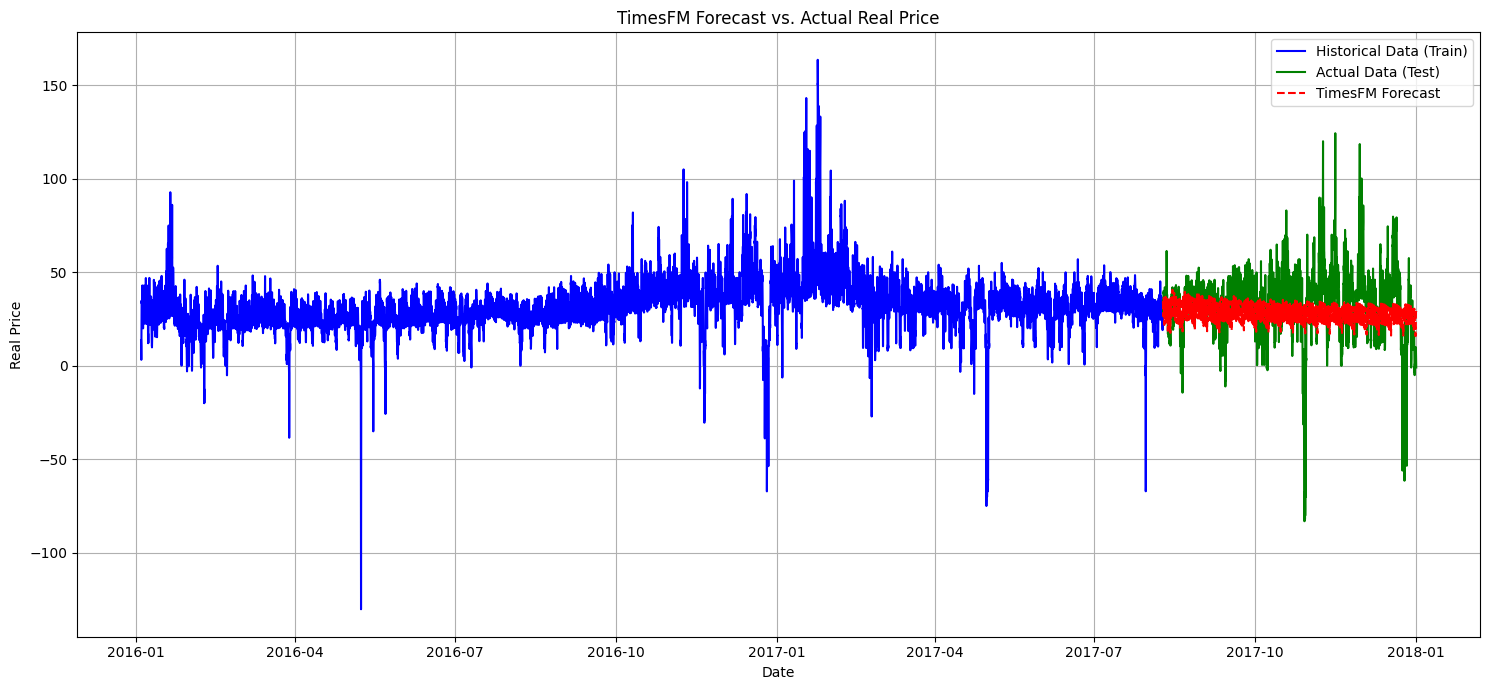

Forecast visualization complete.


In [17]:
import matplotlib.pyplot as plt

# Ensure the 'Unnamed: 0' column is in datetime format
data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])

# Create time indices for train and test data
train_time_index = data.loc[train.index, 'Unnamed: 0']
test_time_index = data.loc[test.index, 'Unnamed: 0']

plt.figure(figsize=(15, 7))

# Plot historical data (training data)
plt.plot(train_time_index, train['Real price'], label='Historical Data (Train)', color='blue')

# Plot actual test data
plt.plot(test_time_index, test['Real price'], label='Actual Data (Test)', color='green')

# Plot forecasts
# point_forecasts is a 2D array, typically (num_series, horizon) for TimesFM.
# Since we have one series, it's (1, forecast_horizon).
plt.plot(test_time_index, point_forecasts[0], label='TimesFM Forecast', color='red', linestyle='--')

plt.title('TimesFM Forecast vs. Actual Real Price')
plt.xlabel('Date')
plt.ylabel('Real Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Forecast visualization complete.")

## Evaluate Forecasts: Mean Absolute Error (MAE)

### Subtask:
Calculate the Mean Absolute Error (MAE) between the actual 'Real price' from the test data and the generated TimesFM point forecasts to quantify the model's performance.

In [19]:
from sklearn.metrics import mean_absolute_error

# Extract actual values from the test set
actual_values = test['Real price'].to_numpy()

# Ensure forecasts are in a 1D array, matching the actual_values shape
# point_forecasts is (1, 3472), so we take the first (and only) series
forecast_values = point_forecasts[0]

# Calculate MAE
mae = mean_absolute_error(actual_values, forecast_values)

print(f"Mean Absolute Error (MAE) of TimesFM forecasts: {mae:.2f}")

Mean Absolute Error (MAE) of TimesFM forecasts: 12.86


**Reasoning**:
Now that the model has been successfully loaded and compiled with the correct `max_horizon` and disabled `use_continuous_quantile_head`, I will use the `model.forecast()` method to generate point forecasts for the 'Real price' using the `preprocessed_data` and `forecast_horizon`.



In [16]:
point_forecasts, _ = model.forecast(
    horizon=forecast_horizon,
    inputs=preprocessed_data,
)

print(f"Shape of generated point forecasts: {point_forecasts.shape}")

Shape of generated point forecasts: (1, 3472)


# Task
Load the "Forecasts_DE_DNN_LEAR_ensembles.csv" file and identify the columns that contain forecasts from other ensemble models, then display these column names.

## Load and Inspect Ensemble Data

### Subtask:
Load the 'Forecasts_DE_DNN_LEAR_ensembles.csv' file and inspect its columns to identify forecasts from other ensemble models. Display the available forecast columns.


**Reasoning**:
The subtask requires loading the CSV file, inspecting its columns, and identifying ensemble forecast columns. I will load the CSV, print its column names, filter out the non-forecast columns, and then print the identified ensemble forecast columns.



In [20]:
import pandas as pd
import os

# Define the full path to the CSV file
csv_path = os.path.join("/content", "Laksegate-master-thesis", "POC", "Forecasts_DE_DNN_LEAR_ensembles.csv")

# Load the CSV file into a pandas DataFrame
df_ensembles = pd.read_csv(csv_path)

print("Loaded DataFrame head:")
print(df_ensembles.head())

# Print all column names to inspect them
print("\nAll column names in the DataFrame:")
print(df_ensembles.columns.tolist())

# Identify columns that represent forecasts from other ensemble models
# Exclude 'Unnamed: 0' and 'Real price'
excluded_columns = ['Unnamed: 0', 'Real price']
ensemble_forecast_columns = [col for col in df_ensembles.columns if col not in excluded_columns]

# Store and print the identified ensemble forecast column names
print("\nIdentified ensemble forecast columns:")
print(ensemble_forecast_columns)

Loaded DataFrame head:
            Unnamed: 0  Real price     DNN 1      DNN 2      DNN 3      DNN 4  \
0  2016-01-04 00:00:00       13.78  9.079985  12.374815  10.602676  10.600306   
1  2016-01-04 01:00:00       12.77  6.142382  10.737263   7.159199   7.956757   
2  2016-01-04 02:00:00       10.56  3.542736   9.347174   5.593657   6.404373   
3  2016-01-04 03:00:00        3.87  3.484398   8.976881   4.708006   6.429434   
4  2016-01-04 04:00:00        3.20  4.640604  10.229042   4.688288   7.726181   

   DNN Ensemble  LEAR 56  LEAR 84  LEAR 1092  LEAR 1456  LEAR Ensemble  
0     10.664445  13.0329  11.8312     9.3073     7.2452      10.354150  
1      7.998900  10.6372   8.0028     6.1668     4.1847       7.247875  
2      6.221985   8.9095  10.4478     3.6748     2.6996       6.432925  
3      5.899680   8.2185   8.9046     3.0388     2.7848       5.736675  
4      6.821029   8.4870   9.8111     1.9000     2.4542       5.663075  

All column names in the DataFrame:
['Unnamed: 0', '

## Calculate MAE for Ensemble Models

### Subtask:
For each identified ensemble model's forecast, calculate its Mean Absolute Error (MAE) against the 'Real price' in the test set. Store these MAE values for comparison.


**Reasoning**:
The subtask requires calculating the MAE for each ensemble model identified previously. I will iterate through the `ensemble_forecast_columns`, extract the relevant forecast data from `df_ensembles` for the test period, calculate the MAE against `actual_values`, and store the results in a dictionary, which will then be printed.



In [21]:
from sklearn.metrics import mean_absolute_error

# Initialize a dictionary to store MAE scores for ensemble models
ensemble_mae_scores = {}

# Loop through each ensemble forecast column
for ensemble_column in ensemble_forecast_columns:
    # Extract forecast values for the test set period
    ensemble_forecast_values = df_ensembles.loc[test.index, ensemble_column].to_numpy()

    # Calculate MAE
    mae = mean_absolute_error(actual_values, ensemble_forecast_values)

    # Store the calculated MAE
    ensemble_mae_scores[ensemble_column] = mae

# Print the MAE scores for all ensemble models
print("Mean Absolute Error (MAE) for other ensemble models:")
for model_name, mae_score in ensemble_mae_scores.items():
    print(f"{model_name}: {mae_score:.2f}")

Mean Absolute Error (MAE) for other ensemble models:
DNN 1: 4.62
DNN 2: 4.48
DNN 3: 4.66
DNN 4: 4.37
DNN Ensemble: 4.16
LEAR 56: 5.51
LEAR 84: 5.25
LEAR 1092: 5.07
LEAR 1456: 5.06
LEAR Ensemble: 4.83


## Compare MAE Scores

### Subtask:
Present a clear comparison of the MAE scores for TimesFM and all other ensemble models. This could be in a table or a bar chart.


**Reasoning**:
First, I'll create a combined dictionary that includes the TimesFM MAE and the MAE scores of other ensemble models, as instructed. Then, I will convert this dictionary into a pandas DataFrame for structured comparison and sort it by MAE score.



In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the MAE for TimesFM (from the previous step where 'mae' was calculated)
timesfm_mae = mae

# Create a dictionary for TimesFM MAE
timesfm_mae_dict = {'TimesFM': timesfm_mae}

# Combine TimesFM MAE with the ensemble MAE scores
all_mae_scores = {**timesfm_mae_dict, **ensemble_mae_scores}

# Convert the dictionary to a pandas DataFrame
mae_df = pd.DataFrame(all_mae_scores.items(), columns=['Model', 'MAE'])

# Sort the DataFrame by MAE score in ascending order
mae_df = mae_df.sort_values(by='MAE', ascending=True)

print("Comparative Mean Absolute Error (MAE) Scores:")
print(mae_df.to_string(index=False))

Comparative Mean Absolute Error (MAE) Scores:
        Model      MAE
 DNN Ensemble 4.157691
        DNN 4 4.372047
        DNN 2 4.477140
        DNN 1 4.619058
        DNN 3 4.656575
      TimesFM 4.829230
LEAR Ensemble 4.829230
    LEAR 1456 5.059788
    LEAR 1092 5.066509
      LEAR 84 5.245626
      LEAR 56 5.509857


**Reasoning**:
The previous step successfully created and printed a DataFrame of comparative MAE scores. Now, I will create a bar chart from this DataFrame to visually compare the MAE scores of TimesFM and the other ensemble models, as per the subtask instructions.



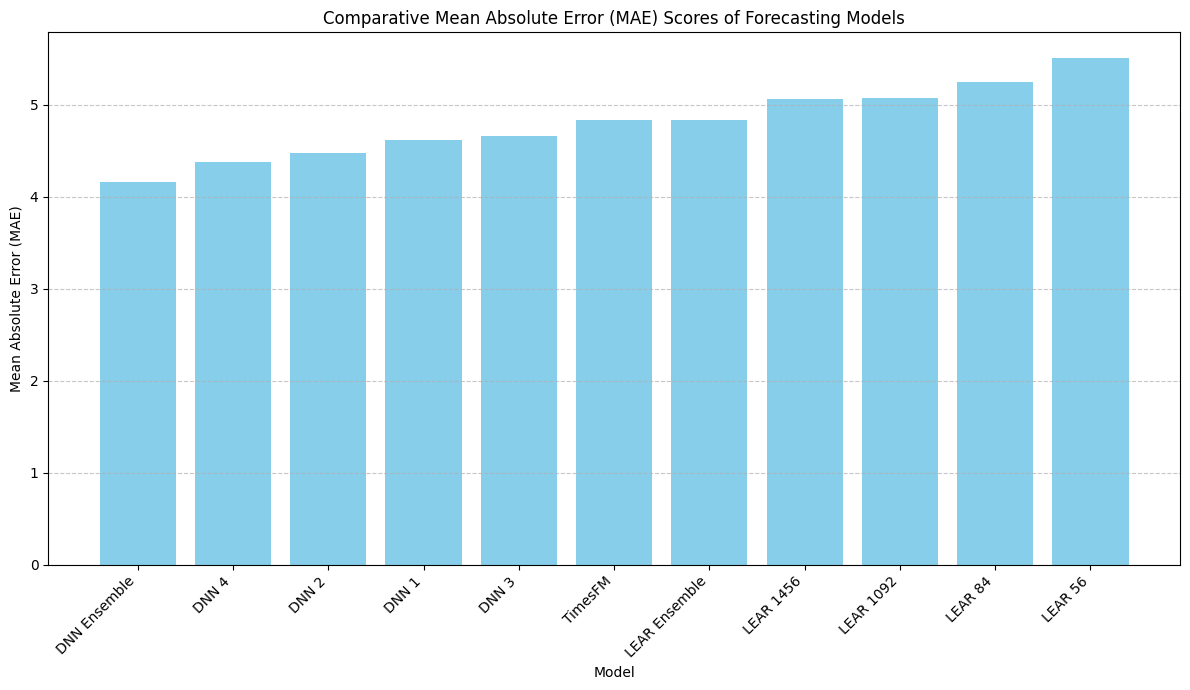

Bar chart displaying comparative MAE scores generated.


In [23]:
import matplotlib.pyplot as plt

# Create a bar chart for visual comparison
plt.figure(figsize=(12, 7))
plt.bar(mae_df['Model'], mae_df['MAE'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Comparative Mean Absolute Error (MAE) Scores of Forecasting Models')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Bar chart displaying comparative MAE scores generated.")

## Visualize Comparative Forecasts

### Subtask:
Create a visualization that plots the actual 'Real price' from the test set, the TimesFM forecast, and forecasts from a selection of the best-performing ensemble models (e.g., top 2-3) for visual comparison. Include labels and a legend.


**Reasoning**:
I need to identify the top performing ensemble models, then plot the historical data, actual test data, TimesFM forecasts, and the selected ensemble forecasts on a single graph for visual comparison, adding all necessary plot elements like title, labels, and legend.



Top 3 best-performing ensemble models: ['DNN Ensemble', 'DNN 4', 'DNN 2']


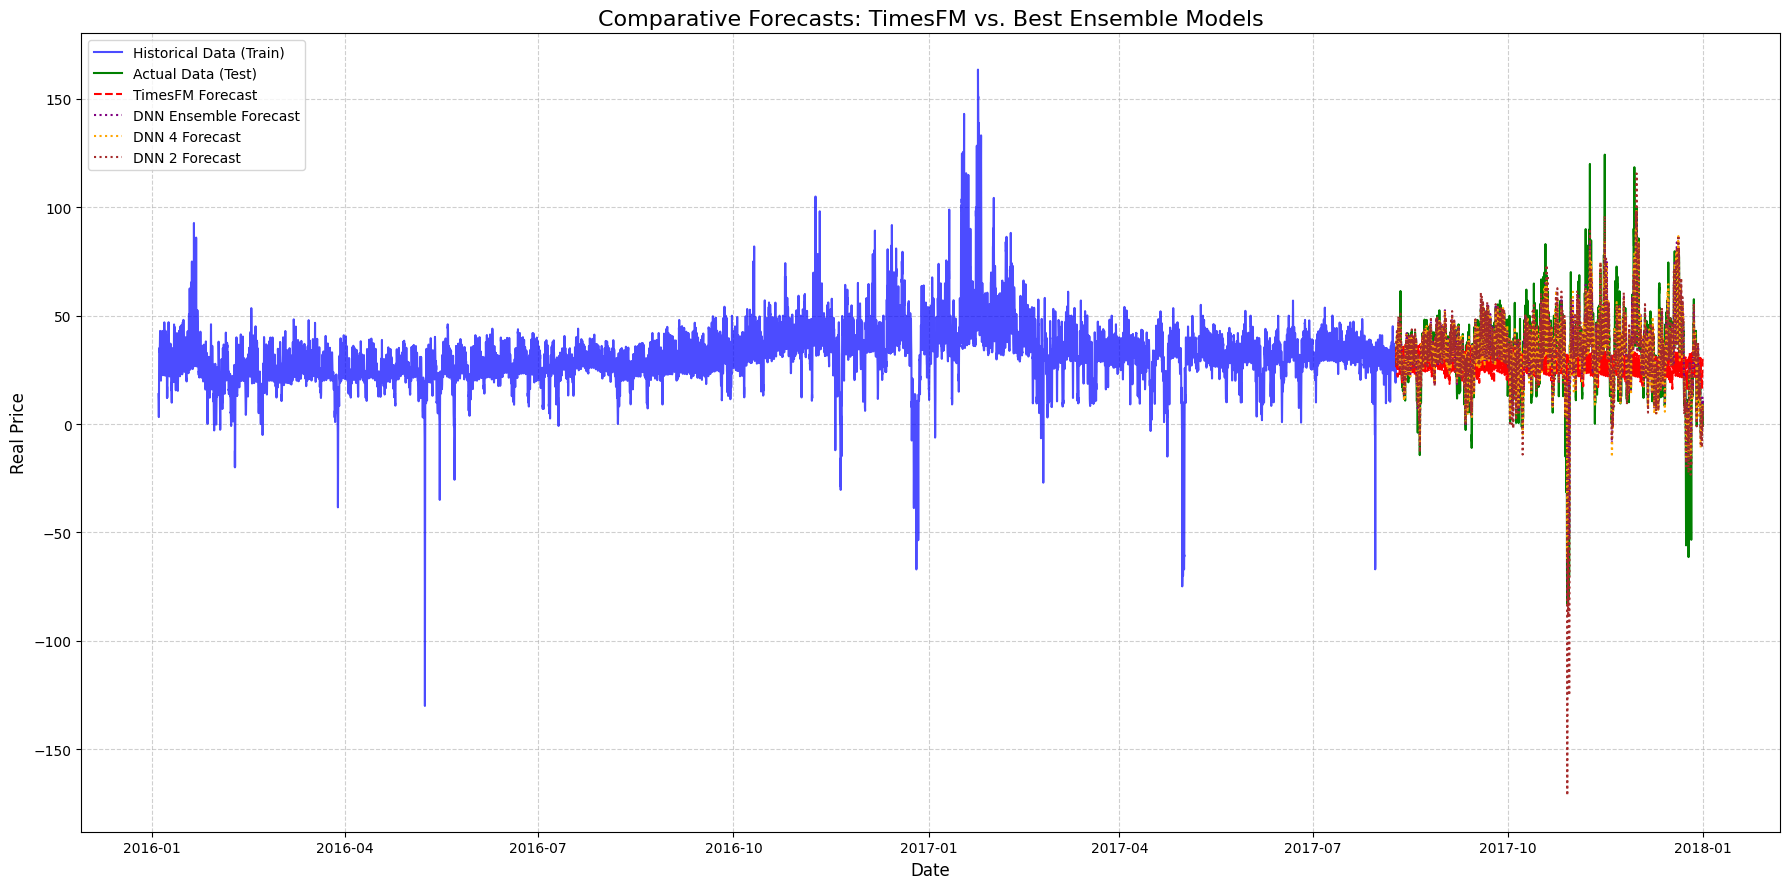

Comparative forecast visualization complete.


In [24]:
import matplotlib.pyplot as plt

# 1. Identify the top 2-3 best-performing ensemble models
# mae_df is already sorted by MAE in ascending order. We will pick the top 3 ensemble models.
top_ensemble_models = mae_df[mae_df['Model'] != 'TimesFM']['Model'].head(3).tolist()
print(f"Top 3 best-performing ensemble models: {top_ensemble_models}")

# 2. Create a new figure and axes for the plot
plt.figure(figsize=(18, 9))

# 3. Plot historical 'Real price' data
plt.plot(train_time_index, train['Real price'], label='Historical Data (Train)', color='blue', alpha=0.7)

# 4. Plot actual 'Real price' data from the test DataFrame
plt.plot(test_time_index, test['Real price'], label='Actual Data (Test)', color='green')

# 5. Plot the TimesFM forecasts
plt.plot(test_time_index, point_forecasts[0], label='TimesFM Forecast', color='red', linestyle='--')

# 6. For each of the selected best-performing ensemble models, plot their forecasts
colors = ['purple', 'orange', 'brown'] # Assign different colors for clarity
for i, model_name in enumerate(top_ensemble_models):
    ensemble_forecast_values = df_ensembles.loc[test.index, model_name].to_numpy()
    plt.plot(test_time_index, ensemble_forecast_values, label=f'{model_name} Forecast', color=colors[i], linestyle=':')

# 7. Add a title
plt.title('Comparative Forecasts: TimesFM vs. Best Ensemble Models', fontsize=16)

# 8. Label the x-axis and y-axis
plt.xlabel('Date', fontsize=12)
plt.ylabel('Real Price', fontsize=12)

# 9. Add a legend
plt.legend(fontsize=10, loc='upper left')

# 10. Add a grid
plt.grid(True, linestyle='--', alpha=0.6)

# 11. Use plt.tight_layout()
plt.tight_layout()

# 12. Display the plot
plt.show()

print("Comparative forecast visualization complete.")